In [35]:
from scipy.cluster.hierarchy import linkage
from sklearn.datasets import make_blobs, make_moons
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from matplotlib import cm
from scipy.spatial.distance import pdist,squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

In [2]:
X, y = make_blobs(n_samples=150, n_features=2, centers=3, cluster_std=0.5, shuffle=True, random_state=0)

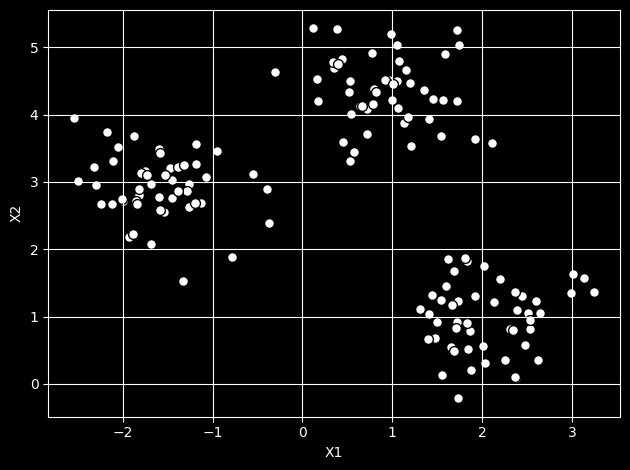

In [3]:
plt.scatter(X[:, 0], X[:, 1], c='white', marker='o', s=50, edgecolor='black')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid()
plt.tight_layout()
plt.show()

In [4]:
km = KMeans(n_clusters=3, init='random', n_init=10, max_iter=300, tol=1e-04, random_state=0)
y_km = km.fit_predict(X)

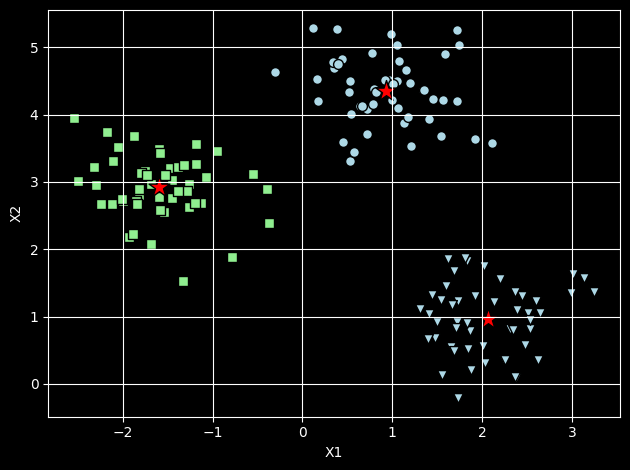

In [5]:
plt.scatter(X[y_km == 0, 0], X[y_km == 0, 1], s=50, c='lightgreen', marker='s', edgecolor='black', label='Cluster 1')
plt.scatter(X[y_km == 1, 0], X[y_km == 1, 1], s=50, c='lightblue', marker='o', edgecolor='black', label='Cluster 2')
plt.scatter(X[y_km == 2, 0], X[y_km == 2, 1], s=50, c='lightblue', marker='v', edgecolor='black', label='Cluster 3')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:,1], s=250, c='red', marker='*', edgecolor='black', label='Centroids')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid()
plt.tight_layout()
plt.show()

In [6]:
print(f'Distortion: {km.inertia_:.2f}')

Distortion: 72.48


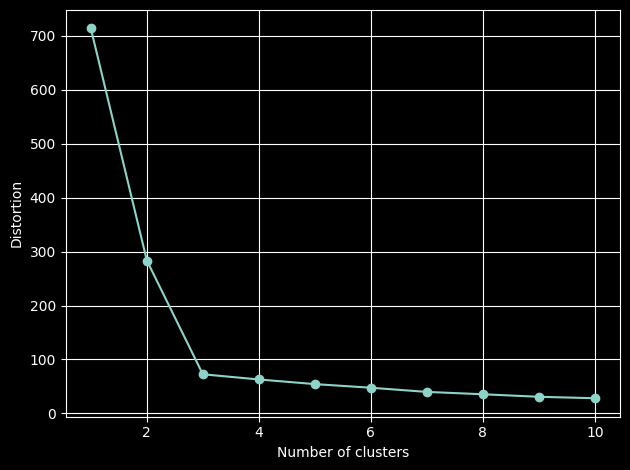

In [7]:
distortion = []
for i in range(1,11):
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=300, random_state=0)
    km.fit(X)
    distortion.append(km.inertia_)
plt.plot(range(1,11), distortion, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.grid()
plt.tight_layout()
plt.show()

In [8]:
km = KMeans(n_clusters=3,
            init='k-means++',
            n_init=10,
            max_iter=300,
            tol=1e-04,
            random_state=0)
y_km = km.fit_predict(X)

cluster_labels = np.unique(y_km)
n_clusters = cluster_labels.shape[0]
silhouette_vals = silhouette_samples(X, y_km, metric='euclidean')
y_ax_lower, y_ax_upper = 0, 0
yticks = []

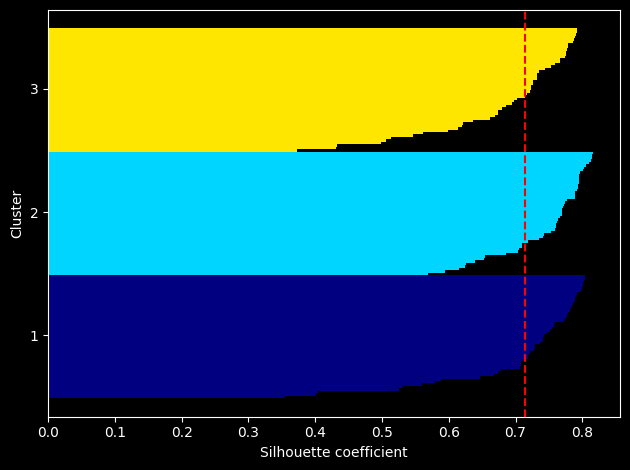

In [9]:
for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_km == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0,
             edgecolor='none', color=color)

    yticks.append((y_ax_lower + y_ax_upper) / 2.)
    y_ax_lower += len(c_silhouette_vals)

silhouette_avg = np.mean(silhouette_vals)
plt.axvline(silhouette_avg, color="red", linestyle="--")

plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')

plt.tight_layout()
# plt.savefig('./figures/silhouette.png', dpi=300)
plt.show()

In [10]:
km = KMeans(n_clusters=2, init='k-means++', n_init=10, max_iter=300, tol=1e-04, random_state=0)
y_km = km.fit_predict(X)

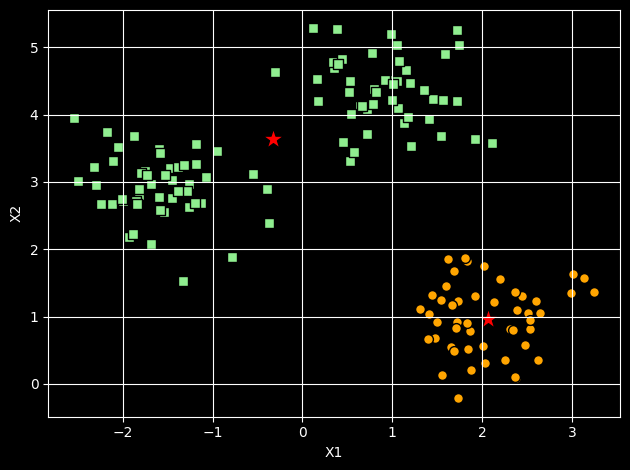

In [11]:
plt.scatter(X[y_km == 0, 0], X[y_km == 0, 1], s=50, c='lightgreen', marker='s', edgecolor='black', label='Cluster 1')
plt.scatter(X[y_km == 1, 0], X[y_km == 1, 1], s=50, c='orange', marker='o', edgecolor='black', label='Cluster 2')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:,1], s=250, c='red', marker='*', edgecolor='black', label='Centroids')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid()
plt.tight_layout()
plt.show()

In [12]:
cluster_labels = np.unique(y_km)
n_clusters = cluster_labels.shape[0]
silhouette_vals = silhouette_samples(X, y_km, metric='euclidean')
y_ax_lower, y_ax_upper = 0, 0
yticks = []

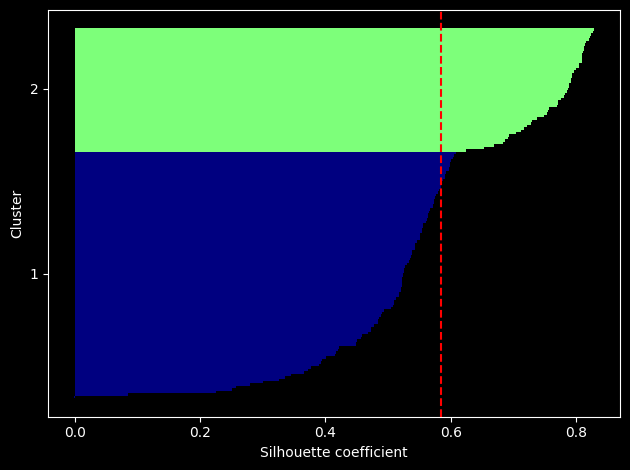

In [13]:
for i, c in enumerate(cluster_labels):
    c_silhouette_vals = silhouette_vals[y_km == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0,
             edgecolor='none', color=color)

    yticks.append((y_ax_lower + y_ax_upper) / 2.)
    y_ax_lower += len(c_silhouette_vals)

silhouette_avg = np.mean(silhouette_vals)
plt.axvline(silhouette_avg, color="red", linestyle="--")

plt.yticks(yticks, cluster_labels + 1)
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')

plt.tight_layout()
# plt.savefig('./figures/silhouette.png', dpi=300)
plt.show()

In [14]:
np.random.seed(123)

variables = ['X', 'Y', 'Z']
labels = ['ID_0', 'ID_1', 'ID_2', 'ID_3', 'ID_4']

X = np.random.random_sample([5, 3])*10
df = pd.DataFrame(X, columns=variables, index=labels)
df

,X,Y,Z
ID_0,6.964692,2.861393,2.268515
ID_1,5.513148,7.194690,4.231065
ID_2,9.807642,6.848297,4.809319
ID_3,3.921175,3.431780,7.290497
ID_4,4.385722,0.596779,3.980443


In [15]:
row_dist = pd.DataFrame( squareform(pdist(df, 'euclidean')), columns=labels, index=labels )
row_dist

,ID_0,ID_1,ID_2,ID_3,ID_4
ID_0,0.000000,4.973534,5.516653,5.899885,3.835396
ID_1,4.973534,0.000000,4.347073,5.104311,6.698233
ID_2,5.516653,4.347073,0.000000,7.244262,8.316594
ID_3,5.899885,5.104311,7.244262,0.000000,4.382864
ID_4,3.835396,6.698233,8.316594,4.382864,0.000000


In [16]:
#row_cluster = linkage(row_dist, method='complete', metric='euclidean')
row_cluster = linkage(pdist(df, metric='euclidean'), method='complete')

In [17]:
row_cluster = linkage(df.values, method='complete', metric='euclidean')

In [18]:
pd.DataFrame(row_cluster, columns=['row label', 'row label', 'distance', 'no. of items in clust.'], index=[f'cluster {(i + 1)}' for i in range(row_cluster.shape[0])])

,row label,row label,distance,no. of items in clust.
cluster 1,0.0,4.0,3.835396,2.0
cluster 2,1.0,2.0,4.347073,2.0
cluster 3,3.0,5.0,5.899885,3.0
cluster 4,6.0,7.0,8.316594,5.0


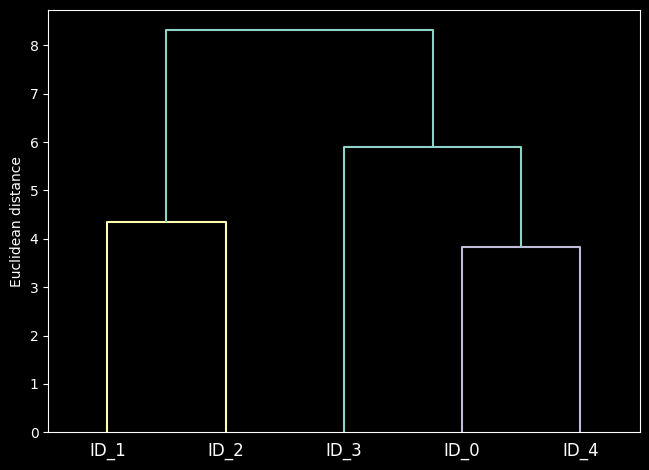

In [19]:
row_dendr = dendrogram( row_cluster, labels=labels)
plt.tight_layout()
plt.ylabel('Euclidean distance')
plt.show()

Index(['ID_4', 'ID_0', 'ID_3', 'ID_2', 'ID_1'], dtype='object')
Index(['X', 'Y', 'Z'], dtype='object')


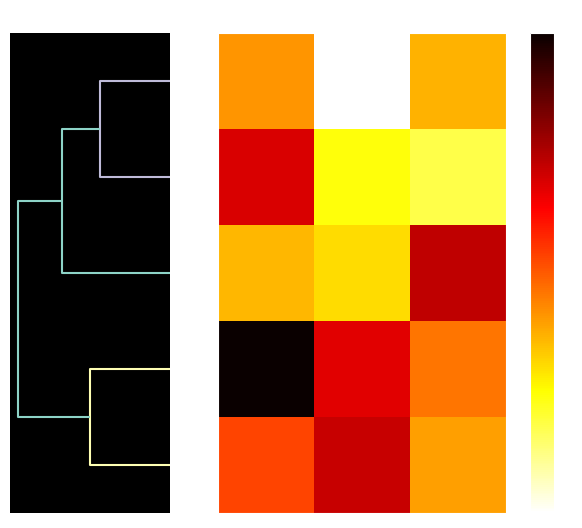

In [20]:
fig = plt.figure(figsize=(8, 8), facecolor='white')
adx = fig.add_axes([0.09, 0.1, 0.2, 0.6])
row_dendr = dendrogram( row_cluster, orientation='left')

df_rowclust = df.iloc[row_dendr['leaves'][::-1]]
axm = fig.add_axes([0.23, 0.1, 0.6, 0.6])
cax = axm.matshow(df_rowclust, interpolation='nearest', cmap='hot_r')

print(df_rowclust.index)
print(df_rowclust.columns)


adx.set_xticks([])
adx.set_yticks([])
for i in adx.spines.values():
    i.set_visible(False)
fig.colorbar(cax)
#axm.set_xticklabels([''] + list(df_rowclust.columns))
#axm.set_yticklabels(list(df_rowclust.index))
plt.show()

In [24]:
ac = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='complete')
labels = ac.fit_predict(X)
print(f'Cluster labels: {labels}')

Cluster labels: [1 0 0 2 1]


In [25]:
ac = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='complete')
labels = ac.fit_predict(X)
print(f'Cluster labels: {labels}')

Cluster labels: [0 1 1 0 0]


In [29]:
X, y = make_moons( n_samples=200, noise=0.05, random_state=0 )


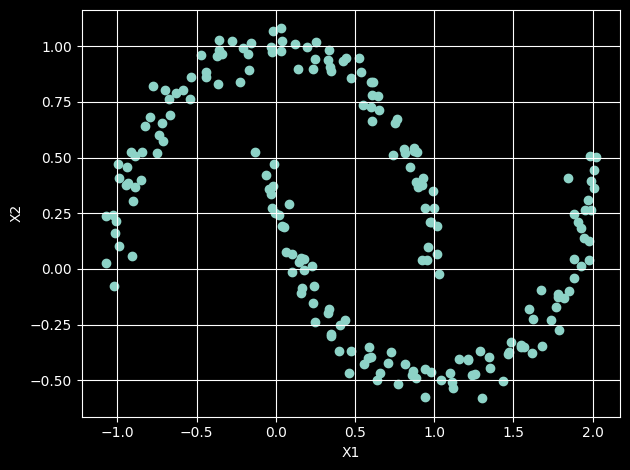

In [30]:
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid()
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Feature 2')

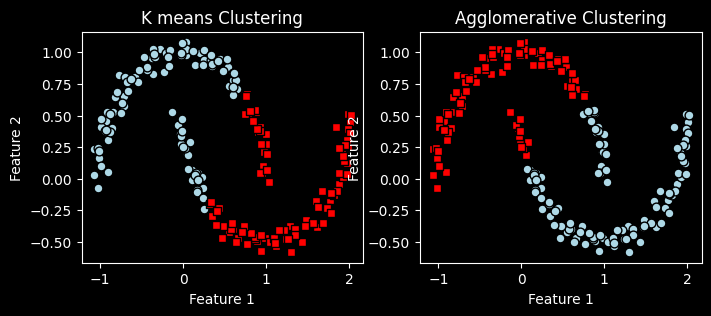

In [34]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
km = KMeans(n_clusters=2, random_state=0)
y_km = km.fit_predict(X)

ax1.scatter(X[y_km == 0, 0], X[y_km == 0, 1], c='lightblue', edgecolors='black', marker='o', s=40, label='Cluster 1')
ax1.scatter(X[y_km == 1, 0], X[y_km == 1, 1], c='red', edgecolors='black', marker='s', s=40, label='Cluster 2')

ax1.set_title('K means Clustering')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')


ac = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='complete')
y_ac = ac.fit_predict(X)


ax2.scatter(X[y_ac == 0, 0], X[y_ac == 0, 1], c='lightblue', edgecolors='black', marker='o', s=40, label='Cluster 1')
ax2.scatter(X[y_ac == 1, 0], X[y_ac == 1, 1], c='red', edgecolors='black', marker='s', s=40, label='Cluster 2')

ax2.set_title('Agglomerative Clustering')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')



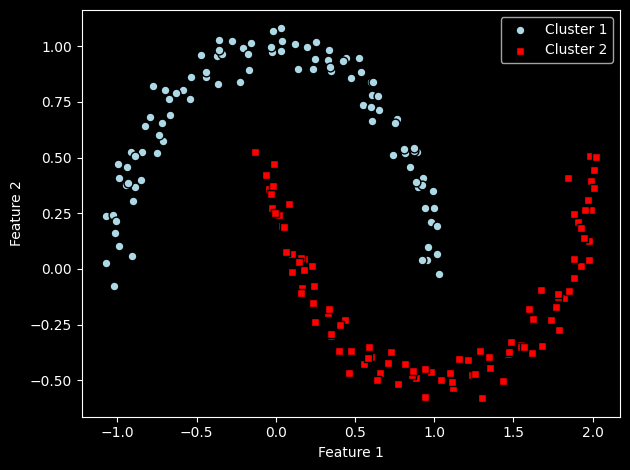

In [39]:
db = DBSCAN(eps=0.2, min_samples=5, metric='euclidean')
y_db = db.fit_predict(X)


plt.scatter(X[y_db == 0, 0], X[y_db == 0, 1], c='lightblue', edgecolors='black', marker='o', s=40, label='Cluster 1')
plt.scatter(X[y_db == 1, 0], X[y_db == 1, 1], c='red', edgecolors='black', marker='s', s=40, label='Cluster 2')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()
